**Import packages and read data**

In [20]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
import sqlite3
import warnings
warnings.filterwarnings('ignore')

In [21]:
# Kết nối database
conn = sqlite3.connect('data/oulad.db')

assessment       = pd.read_sql("SELECT * FROM assessments", conn)
courses          = pd.read_sql("SELECT * FROM courses", conn)
student_info     = pd.read_sql("SELECT * FROM studentInfo", conn)
student_regs     = pd.read_sql("SELECT * FROM studentRegistration", conn)
student_assessment = pd.read_sql("SELECT * FROM studentAssessment", conn)
vle              = pd.read_sql("SELECT * FROM vle", conn)

**Assessment data info**

In [22]:
assessment

,code_module,code_presentation,id_assessment,assessment_type,date,weight
0,AAA,2013J,1752,TMA,19,10.0
1,AAA,2013J,1753,TMA,54,20.0
2,AAA,2013J,1754,TMA,117,20.0
3,AAA,2013J,1755,TMA,166,20.0
4,AAA,2013J,1756,TMA,215,30.0
...,...,...,...,...,...,...
201,GGG,2014J,37443,CMA,229,0.0
202,GGG,2014J,37435,TMA,61,0.0
203,GGG,2014J,37436,TMA,124,0.0
204,GGG,2014J,37437,TMA,173,0.0


In [23]:
assessment.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 206 entries, 0 to 205
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   code_module        206 non-null    object 
 1   code_presentation  206 non-null    object 
 2   id_assessment      206 non-null    int64  
 3   assessment_type    206 non-null    object 
 4   date               206 non-null    object 
 5   weight             206 non-null    float64
dtypes: float64(1), int64(1), object(4)
memory usage: 9.8+ KB


In [24]:
assessment['id_assessment'] = assessment['id_assessment'].astype('object')

**Assessment descriptive statistics**

In [25]:
assessment.describe(include='object').T

,count,unique,top,freq
code_module,206,7,FFF,52
code_presentation,206,4,2014J,57
id_assessment,206,206,1752,1
assessment_type,206,3,TMA,106
date,206,75,222,15


**Modules distribution by bar chart**

Text(0.5, 1.0, 'Distribution of Code Modules')

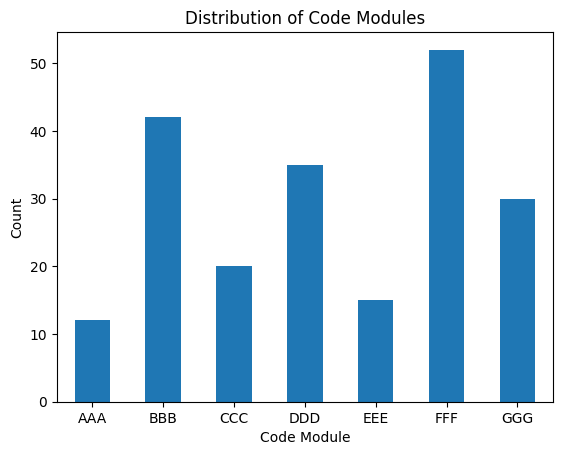

In [26]:
assessment['code_module'].value_counts().sort_index().plot(kind = 'bar', rot = 0)
plt.ylabel('Count')
plt.xlabel('Code Module')
plt.title('Distribution of Code Modules')

**Sum of assessment's weight**

In [27]:
assessment[['code_module','code_presentation','weight']].groupby(['code_module','code_presentation']).sum()

weight
code_module code_presentation        
AAA         2013J               200.0
            2014J               200.0
BBB         2013B               200.0
            2013J               200.0
            2014B               200.0
            2014J               200.0
CCC         2014B               300.0
            2014J               300.0
DDD         2013B               200.0
            2013J               200.0
            2014B               200.0
            2014J               200.0
EEE         2013J               200.0
            2014B               200.0
            2014J               200.0
FFF         2013B               200.0
            2013J               200.0
            2014B               200.0
            2014J               200.0
GGG         2013J               100.0
            2014B               100.0
            2014J               100.0

**Anomaly in GGG and CCC weight**

In [28]:
assessment[assessment['code_module'] == 'GGG']

,code_module,code_presentation,id_assessment,assessment_type,date,weight
176,GGG,2013J,37418,CMA,229,0.0
177,GGG,2013J,37419,CMA,229,0.0
178,GGG,2013J,37420,CMA,229,0.0
179,GGG,2013J,37421,CMA,229,0.0
180,GGG,2013J,37422,CMA,229,0.0
181,GGG,2013J,37423,CMA,229,0.0
182,GGG,2013J,37415,TMA,61,0.0
183,GGG,2013J,37416,TMA,124,0.0
184,GGG,2013J,37417,TMA,173,0.0
185,GGG,2013J,37424,Exam,229,100.0


In [29]:
assessment[assessment['code_module'] == 'CCC']

,code_module,code_presentation,id_assessment,assessment_type,date,weight
54,CCC,2014B,24286,CMA,18,2.0
55,CCC,2014B,24287,CMA,67,7.0
56,CCC,2014B,24288,CMA,137,8.0
57,CCC,2014B,24289,CMA,207,8.0
58,CCC,2014B,24282,TMA,32,9.0
59,CCC,2014B,24283,TMA,102,22.0
60,CCC,2014B,24284,TMA,151,22.0
61,CCC,2014B,24285,TMA,200,22.0
62,CCC,2014B,24290,Exam,?,100.0
63,CCC,2014B,40087,Exam,?,100.0


**Missing values in `date` column**

In [30]:
assessment[assessment.date == '?']

,code_module,code_presentation,id_assessment,assessment_type,date,weight
5,AAA,2013J,1757,Exam,?,100.0
11,AAA,2014J,1763,Exam,?,100.0
23,BBB,2013B,14990,Exam,?,100.0
35,BBB,2013J,15002,Exam,?,100.0
47,BBB,2014B,15014,Exam,?,100.0
53,BBB,2014J,15025,Exam,?,100.0
62,CCC,2014B,24290,Exam,?,100.0
63,CCC,2014B,40087,Exam,?,100.0
72,CCC,2014J,24299,Exam,?,100.0
73,CCC,2014J,40088,Exam,?,100.0


In [31]:
exam_assessment = assessment[assessment.assessment_type == 'Exam']
exam_assessment

,code_module,code_presentation,id_assessment,assessment_type,date,weight
5,AAA,2013J,1757,Exam,?,100.0
11,AAA,2014J,1763,Exam,?,100.0
23,BBB,2013B,14990,Exam,?,100.0
35,BBB,2013J,15002,Exam,?,100.0
47,BBB,2014B,15014,Exam,?,100.0
53,BBB,2014J,15025,Exam,?,100.0
62,CCC,2014B,24290,Exam,?,100.0
63,CCC,2014B,40087,Exam,?,100.0
72,CCC,2014J,24299,Exam,?,100.0
73,CCC,2014J,40088,Exam,?,100.0


In [32]:
exam_length = pd.read_sql("""
    SELECT a.assessment_type, a.date, c.module_presentation_length
    FROM assessments a
    JOIN courses c ON a.code_module = c.code_module
                  AND a.code_presentation = c.code_presentation
    WHERE a.assessment_type = 'Exam'
""", conn)
exam_length

,assessment_type,date,module_presentation_length
0,Exam,?,268
1,Exam,?,269
2,Exam,?,240
3,Exam,?,268
4,Exam,?,234
5,Exam,?,262
6,Exam,?,241
7,Exam,?,241
8,Exam,?,269
9,Exam,?,269


**Student info**

In [ ]:
# Thay thế pd.read_sql(...)
student_df = (
    student_info
    .merge(student_regs, on=['id_student', 'code_module', 'code_presentation'])
    .merge(student_assessment, on='id_student', how='left') 
)
student_df

,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,date_registration,date_unregistration,id_assessment,date_submitted,is_banked,score
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass,-159,?,1752.0,18.0,0.0,78
1,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass,-159,?,1753.0,53.0,0.0,85
2,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass,-159,?,1754.0,115.0,0.0,80
3,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass,-159,?,1755.0,164.0,0.0,85
4,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass,-159,?,1756.0,212.0,0.0,82
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
213161,GGG,2014J,2684003,F,Yorkshire Region,HE Qualification,50-60%,35-55,0,30,N,Distinction,-28,?,37437.0,169.0,0.0,60
213162,GGG,2014J,2684003,F,Yorkshire Region,HE Qualification,50-60%,35-55,0,30,N,Distinction,-28,?,37438.0,73.0,0.0,100
213163,GGG,2014J,2684003,F,Yorkshire Region,HE Qualification,50-60%,35-55,0,30,N,Distinction,-28,?,37439.0,150.0,0.0,60
213164,GGG,2014J,2684003,F,Yorkshire Region,HE Qualification,50-60%,35-55,0,30,N,Distinction,-28,?,37440.0,172.0,0.0,100


**VLE data extraction**

In [66]:
vle_weekly = pd.read_sql("""
    SELECT 
        sv.id_student,
        sv.code_module,
        sv.code_presentation,
        v.activity_type,
        CAST(FLOOR(CAST(sv.date AS FLOAT) / 7) AS INTEGER) AS week,
        SUM(sv.sum_click) AS weekly_clicks
    FROM studentVle sv
    JOIN vle v 
        ON sv.id_site = v.id_site
        AND sv.code_module = v.code_module
        AND sv.code_presentation = v.code_presentation
    GROUP BY sv.id_student, sv.code_module, sv.code_presentation, v.activity_type, week
""", conn)

In [69]:
vle_weekly

,id_student,code_module,code_presentation,activity_type,week,weekly_clicks
0,6516,AAA,2014J,dataplus,4,7
1,6516,AAA,2014J,dataplus,19,7
2,6516,AAA,2014J,dataplus,24,5
3,6516,AAA,2014J,dataplus,26,2
4,6516,AAA,2014J,forumng,-4,33
...,...,...,...,...,...,...
2518165,2698588,BBB,2014J,subpage,31,3
2518166,2698588,BBB,2014J,subpage,32,1
2518167,2698588,BBB,2014J,subpage,33,5
2518168,2698588,BBB,2014J,url,0,1


**Check number of students remaining after every 2 months**

In [ ]:
def test():
    PREDICTION_POINTS = [60, 120, 180, 240]

    # --- Chuẩn bị student_assessment_joined TRƯỚC loop ---
    student_assessment_joined = pd.read_sql("""
        SELECT
            sa.id_student,
            sa.id_assessment,
            sa.date_submitted,
            sa.is_banked,
            sa.score,
            a.code_module,
            a.code_presentation,
            a.assessment_type,
            a.date   AS deadline_raw,
            a.weight
        FROM studentAssessment sa
        JOIN assessments a ON sa.id_assessment = a.id_assessment
    """, conn)

    student_assessment_joined['deadline'] = pd.to_numeric(
        student_assessment_joined['deadline_raw'], errors='coerce'
    ).astype('float')

    student_assessment_joined['score'] = pd.to_numeric(
        student_assessment_joined['score'], errors='coerce'
    ).astype('float')

    student_assessment_joined['days_early'] = (
        student_assessment_joined['deadline'] - student_assessment_joined['date_submitted']
    )

    student_assessment_joined['is_failed'] = (
        student_assessment_joined['score'] < 40
    ).astype(int)
    student_assessment_joined['weighted_score'] = (
        student_assessment_joined['score'] * student_assessment_joined['weight'] / 100
    )

    student_assessment_joined.drop(columns='deadline_raw', inplace=True)

    # Convert date_unregistration sang float để so sánh với T
    student_regs['date_unregistration'] = pd.to_numeric(
        student_regs['date_unregistration'], errors='coerce'
    ).astype('float')


    # --- Loop ---
    for T in PREDICTION_POINTS:

        # --- Chỉ giữ sinh viên còn active tại thời điểm T ---
        active_students = student_regs[
            (student_regs['date_unregistration'].isna()) |
            (student_regs['date_unregistration'] > T)
        ][['id_student', 'code_module', 'code_presentation']]

        # VLE features
        vle_feat = (
            vle_weekly[vle_weekly['week'] <= T // 7]
            .groupby(['id_student', 'code_module', 'code_presentation'])
            .agg(
                total_clicks      = ('weekly_clicks', 'sum'),
                active_weeks      = ('week', 'nunique'),
            )
            .reset_index()
        )
        vle_feat['avg_weekly_clicks'] = vle_feat['total_clicks'] / vle_feat['active_weeks']
        
        # Assessment features
        # Bài phải thi tính đến T (theo lịch module, không phụ thuộc sinh viên)
        num_due_per_module = assessment.copy()
        num_due_per_module['date_num'] = pd.to_numeric(num_due_per_module['date'], errors='coerce')

        num_due_per_module = (
            num_due_per_module[num_due_per_module['date_num'] <= T]
            .groupby(['code_module', 'code_presentation'])
            .agg(num_due=('id_assessment', 'count'))
            .reset_index()
        )
        return num_due_per_module

        # Chỉ lấy bài có deadline <= T VÀ đã nộp trước T (tránh data leakage)
        submitted_in_window = student_assessment_joined[
            (student_assessment_joined['deadline'] <= T) &
            (student_assessment_joined['date_submitted'] <= T)
        ]

        assess_feat = (
            submitted_in_window
            .groupby(['id_student', 'code_module', 'code_presentation'])
            .agg(
                num_submitted  = ('id_assessment', 'count'),
                total_w_score  = ('weighted_score', 'sum'),  # Σ(score × weight / 100)
                total_weight   = ('weight', 'sum'),           # Σ weight
                avg_days_early = ('days_early', 'mean'),
                num_failed     = ('is_failed', 'sum'),
            )
            .reset_index()
        )

        # Weighted average score = Σ(score × weight) / Σ(weight)
        assess_feat['avg_score'] = (
            assess_feat['total_w_score'] * 100 / assess_feat['total_weight'].replace(0, pd.NA)
        )
        assess_feat['avg_score'] = pd.to_numeric(assess_feat['avg_score'], errors='coerce').round(2)
        assess_feat['avg_days_early'] = assess_feat['avg_days_early'].round(2)

        assess_feat.drop(columns=['total_w_score', 'total_weight'], inplace=True)

        # Gắn num_due và tính submission_rate
        assess_feat = assess_feat.merge(
            num_due_per_module, on=['code_module', 'code_presentation'], how='left'
        )
        assess_feat['submission_rate'] = assess_feat['num_submitted'] / assess_feat['num_due']

        display(assess_feat[assess_feat['submission_rate'] < 1.0])
        return 
        # Static features + label — chỉ lấy sinh viên còn active
        static = student_info[[
            'id_student', 'code_module', 'code_presentation',
            'gender', 'region', 'highest_education', 'imd_band',
            'age_band', 'num_of_prev_attempts', 'studied_credits',
            'disability', 'final_result'
        ]].merge(
            active_students,
            on=['id_student', 'code_module', 'code_presentation'],
            how='inner'
        )

        # Merge
        df_T = (
            static
            .merge(vle_feat,    on=['id_student', 'code_module', 'code_presentation'], how='left')
            .merge(assess_feat, on=['id_student', 'code_module', 'code_presentation'], how='left')
        )
        df_T['prediction_point'] = T
        print(f"T={T} days → {len(df_T):,} students remaining")
        display(df_T.head())

test()

,code_module,code_presentation,id_assessment,assessment_type,date,weight,date_num
0,AAA,2013J,1752,TMA,19,10.0,19.0
1,AAA,2013J,1753,TMA,54,20.0,54.0
2,AAA,2013J,1754,TMA,117,20.0,117.0
3,AAA,2013J,1755,TMA,166,20.0,166.0
4,AAA,2013J,1756,TMA,215,30.0,215.0
...,...,...,...,...,...,...,...
201,GGG,2014J,37443,CMA,229,0.0,229.0
202,GGG,2014J,37435,TMA,61,0.0,61.0
203,GGG,2014J,37436,TMA,124,0.0,124.0
204,GGG,2014J,37437,TMA,173,0.0,173.0


In [121]:
%whos DataFrame

Variable             Type         Data/Info
-------------------------------------------
assessment           DataFrame        code_module code_pres<...>n\n[206 rows x 6 columns]
courses              DataFrame       code_module code_prese<...>                      241
df                   DataFrame            id_student  activ<...>[220871 rows x 3 columns]
df_grouped           DataFrame            id_student code_m<...>[627031 rows x 5 columns]
exam_assessment      DataFrame        code_module code_pres<...>        Exam  229   100.0
exam_length          DataFrame       assessment_type date  <...>                      269
student_assessment   DataFrame            id_assessment  id<...>[173912 rows x 5 columns]
student_df           DataFrame           code_module code_p<...>213166 rows x 18 columns]
student_info         DataFrame          code_module code_pr<...>[32593 rows x 12 columns]
student_regs         DataFrame          code_module code_pr<...>n[32593 rows x 5 columns]
student_vle_